# Challenge details

Please find a few remarks to help you get started:

Our sales process starts at “Opportunity Accepted” and goes until “Deploy”, where the opportunity is considered won.
“Closed Lost” indicates opportunities that were pursued but not won.
Qualified Out means the opportunity was presented to our sales Manager but was not accepted.
Lead Source indicates where the opportunity originated, while Campaign reflects the marketing initiative that generated it.
“Meeting Set”, “Meeting Rescheduled”, and “Meeting Finished” are opportunity stages prior to “Opportunity Accepted”. These are primarily used by our SDR and Alliance teams (and occasionally others) to pass potential opportunities to Sales.
 

Based on this data, please share the top three key insights that you believe the company should be aware of.
Kindly focus your analysis specifically on opportunities of type “New Business” and “Upsells.”

In [2633]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import openpyxl

import warnings
warnings.filterwarnings('ignore')

In [2634]:
# Reading the sales opportunity data from an Excel file

df = pd.read_excel('Test Data For Customer Success.xlsx')

# Basic details of the provided data

In [2635]:
df.head()

,Opportunity Owner,Account Name,Opportunity Name,Stage,Fiscal Period,Annual Contract Value Currency,Annual Contract Value,Probability (%),Age,Estimated Close Date,Created Date,Lead Source,Primary Campaign Source,Opportunity Type
0,Sales Manager 11,Customer 1,Opportunity 1,Closed Lost,Q3-2024,EUR,80000.0,0,1098,2024-09-15,2021-09-14,DHL Referral,NaN,New Business
1,Sales Manager 8,Customer 2,Opportunity 2,Qualified Out,Q3-2024,USD,200000.0,0,969,2024-07-12,2021-11-16,SDR Team,NaN,New Business
2,Sales Manager 6,Customer 3,Opportunity 3,Closed Lost,Q4-2024,USD,550000.0,0,1117,2024-12-20,2021-11-29,Outside Sales,NaN,New Business
3,Sales Manager 11,Customer 4,Opportunity 4,Closed Lost,Q2-2024,EUR,250000.0,0,785,2024-06-27,2022-05-04,Marketing,NaN,New Business
4,Sales Manager 3,Customer 5,Opportunity 5,Qualified Out,Q4-2024,USD,269500.0,0,870,2024-10-25,2022-06-08,Customer Success,NaN,Up-Sell


In [2636]:
df.describe().round()

,Annual Contract Value,Probability (%),Age,Estimated Close Date,Created Date
count,400.0,555.0,555.0,555,555
mean,134180.0,16.0,291.0,2024-08-05 11:58:42.162162176,2023-11-26 07:49:37.297297408
min,0.0,0.0,0.0,2024-01-01 00:00:00,2021-09-14 00:00:00
25%,19750.0,0.0,230.0,2024-05-30 12:00:00,2023-08-08 00:00:00
50%,100000.0,0.0,297.0,2024-08-15 00:00:00,2024-01-11 00:00:00
75%,180000.0,25.0,320.0,2024-10-31 00:00:00,2024-03-18 00:00:00
max,1350000.0,100.0,1117.0,2024-12-31 00:00:00,2025-01-08 00:00:00
std,165218.0,31.0,160.0,NaN,NaN


In [2637]:
df.columns

Index(['Opportunity Owner', 'Account Name', 'Opportunity Name', 'Stage',
       'Fiscal Period', 'Annual Contract Value Currency',
       'Annual Contract Value', 'Probability (%)', 'Age',
       'Estimated Close Date', 'Created Date', 'Lead Source',
       'Primary Campaign Source', 'Opportunity Type'],
      dtype='object')

In [2638]:
#Data types of each column

df.dtypes

Opportunity Owner                         object
Account Name                              object
Opportunity Name                          object
Stage                                     object
Fiscal Period                             object
Annual Contract Value Currency            object
Annual Contract Value                    float64
Probability (%)                            int64
Age                                        int64
Estimated Close Date              datetime64[ns]
Created Date                      datetime64[ns]
Lead Source                               object
Primary Campaign Source                   object
Opportunity Type                          object
dtype: object

In [2639]:
#Shape of the DataFrame
df.shape

(555, 14)

In [2640]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Opportunity Owner               555 non-null    object        
 1   Account Name                    555 non-null    object        
 2   Opportunity Name                555 non-null    object        
 3   Stage                           555 non-null    object        
 4   Fiscal Period                   555 non-null    object        
 5   Annual Contract Value Currency  400 non-null    object        
 6   Annual Contract Value           400 non-null    float64       
 7   Probability (%)                 555 non-null    int64         
 8   Age                             555 non-null    int64         
 9   Estimated Close Date            555 non-null    datetime64[ns]
 10  Created Date                    555 non-null    datetime64[ns]
 11  Lead S

- Some of the columns has null values

---

# PRE-PROCESSING OF THE DATA

## Checking Duplicate Records

In [2641]:
# Removig duplicates
df.duplicated().sum()

# Zero duplicate rows found

np.int64(0)

## Checking inconsistency with 'Opportunity Name' column

In [2642]:
# Checking whether there is any inconsistency in the opportunity name column
# Opportunity need to be unique in order to proceed for the analysis

df['Opportunity_Name_Pre'] = df['Opportunity Name'].apply(lambda x: x.strip().upper().replace('OPPORTUNITY', ''))
Opporunity_values = df['Opportunity_Name_Pre'].value_counts().index.str.strip()

# With this check we indentified that there are no inconsistencies in the opportunity name column as the total count of opportunity names is equal to the number of rows in the dataset.

In [2643]:
Opporunity_values = [int(i) for i in Opporunity_values]
Actual_oppotunity = [i for i in range(1, max(Opporunity_values)+1, 1)]

# Missing opportunity details [SOFT CHECK]
Missing_opportunity_data = set(Actual_oppotunity) - set(Opporunity_values)

print('Data missing for the following opportunity numbers:')
print(sorted(Missing_opportunity_data))
print('Does not impact the analysis as these opportunity numbers are not present in the dataset.')

Data missing for the following opportunity numbers:
[13, 25, 43, 57, 58, 60, 61, 62, 71, 77, 88, 91, 98, 99, 100, 110, 133, 137, 138, 143, 147, 150, 175, 180, 185, 199, 201, 243, 257, 282, 285, 316, 329, 573]
Does not impact the analysis as these opportunity numbers are not present in the dataset.


In [2644]:
# --- IGNORE ---

## Dropping 'Account Name', 'Opportunity_Name_Pre', 'Opportunity Name'

In [2645]:
df['Account Name'].value_counts().sum()

# All are unique account names so can be dropped from the analysis

np.int64(555)

In [2646]:
df.drop(axis=1, columns = ['Account Name', 'Opportunity_Name_Pre', 'Opportunity Name'], inplace=True)

In [2647]:
df

,Opportunity Owner,Stage,Fiscal Period,Annual Contract Value Currency,Annual Contract Value,Probability (%),Age,Estimated Close Date,Created Date,Lead Source,Primary Campaign Source,Opportunity Type
0,Sales Manager 11,Closed Lost,Q3-2024,EUR,80000.0,0,1098,2024-09-15,2021-09-14,DHL Referral,NaN,New Business
1,Sales Manager 8,Qualified Out,Q3-2024,USD,200000.0,0,969,2024-07-12,2021-11-16,SDR Team,NaN,New Business
2,Sales Manager 6,Closed Lost,Q4-2024,USD,550000.0,0,1117,2024-12-20,2021-11-29,Outside Sales,NaN,New Business
3,Sales Manager 11,Closed Lost,Q2-2024,EUR,250000.0,0,785,2024-06-27,2022-05-04,Marketing,NaN,New Business
4,Sales Manager 3,Qualified Out,Q4-2024,USD,269500.0,0,870,2024-10-25,2022-06-08,Customer Success,NaN,Up-Sell
...,...,...,...,...,...,...,...,...,...,...,...,...
550,Sales Manager 14,Qualified Out,Q3-2024,NaN,NaN,0,73,2024-08-12,2024-05-31,Marketing,NaN,New Business
551,Sales Manager 12,Deploy,Q4-2024,USD,3260.0,100,0,2024-10-02,2024-11-26,Customer Success,NaN,Up-Sell
552,Sales Manager 16,Deploy,Q4-2024,USD,8000.0,100,12,2024-12-09,2024-11-27,Outside Sales,NaN,Up-Sell
553,Sales Manager 12,Deploy,Q4-2024,USD,6254.0,100,1,2024-12-31,2024-12-30,Outside Sales,NaN,Renewal


## Null value handling

In [2648]:
# Working on Null values

# Count of null values in each column 

Null_values_count = df.isnull().sum() 
Null_values_count[Null_values_count > 0]

Annual Contract Value Currency    155
Annual Contract Value             155
Lead Source                       121
Primary Campaign Source           388
Opportunity Type                    7
dtype: int64

In [2649]:
# Percentage of null values in each column 

Null_values_per = round((df.isnull().sum()/df.shape[0] )* 100, 2)
Null_values_per[Null_values_per > 0]

Annual Contract Value Currency    27.93
Annual Contract Value             27.93
Lead Source                       21.80
Primary Campaign Source           69.91
Opportunity Type                   1.26
dtype: float64

## Dropping of Primary Campaign Source

In [2650]:
# Values in Primary Campaign Source column are missing for around 69.91% of the data. Hence dropping this column from the analysis.
df.drop(axis=1, columns = ['Primary Campaign Source'], inplace=True)

## Handling of Null values in 'Opportunity Type' column

In [2651]:
# Values in Opportunity type column are missing for around 1% of the data. Hence replacing the missing values with mode of the column
df['Opportunity Type'].fillna(df['Opportunity Type'].mode()[0], inplace=True)

## Dropping Estimated Close Date' & 'Created Date'

In [2652]:
# As Age is the column which is difference between Estimated Close Date & Created Date, we will drop these columns from the analysis
df.drop(axis = 1, columns = ['Estimated Close Date', 'Created Date'], inplace=True)

In [2653]:
df.head()

,Opportunity Owner,Stage,Fiscal Period,Annual Contract Value Currency,Annual Contract Value,Probability (%),Age,Lead Source,Opportunity Type
0,Sales Manager 11,Closed Lost,Q3-2024,EUR,80000.0,0,1098,DHL Referral,New Business
1,Sales Manager 8,Qualified Out,Q3-2024,USD,200000.0,0,969,SDR Team,New Business
2,Sales Manager 6,Closed Lost,Q4-2024,USD,550000.0,0,1117,Outside Sales,New Business
3,Sales Manager 11,Closed Lost,Q2-2024,EUR,250000.0,0,785,Marketing,New Business
4,Sales Manager 3,Qualified Out,Q4-2024,USD,269500.0,0,870,Customer Success,Up-Sell


In [2654]:
df.isnull().sum() 

Opportunity Owner                   0
Stage                               0
Fiscal Period                       0
Annual Contract Value Currency    155
Annual Contract Value             155
Probability (%)                     0
Age                                 0
Lead Source                       121
Opportunity Type                    0
dtype: int64

## Handling of 'Annual Contract Value Currency' & 'Annual Contract Value' for ('Closed Lost', 'Qualified Out')

In [2655]:
# When stage of the opportunity is Closed Lost or Qualified Out, will not have any value in Annual Contract Value Currency, Annual Contract Value.
# Replacing the null values in these columns with 0

# For the 'No Currency' fill
df.loc[df['Stage'].isin(['Closed Lost', 'Qualified Out']), 'Annual Contract Value Currency'] = df.loc[df['Stage'].isin(['Closed Lost', 'Qualified Out']), 'Annual Contract Value Currency'].fillna('No Currency')
df.loc[df['Stage'].isin(['Closed Lost', 'Qualified Out']), 'Annual Contract Value'] = df.loc[df['Stage'].isin(['Closed Lost', 'Qualified Out']), 'Annual Contract Value'].fillna(0)

## Handling of 'Lead Source'

In [2656]:
# As the Lead Source is ~20% missing, we will replace the missing values with Mode of the column
df['Lead Source'].fillna(df['Lead Source'].mode()[0], inplace=True)

In [2657]:
df.isnull().sum()

Opportunity Owner                  0
Stage                              0
Fiscal Period                      0
Annual Contract Value Currency    17
Annual Contract Value             17
Probability (%)                    0
Age                                0
Lead Source                        0
Opportunity Type                   0
dtype: int64

In [2658]:
df[df['Annual Contract Value Currency'].isnull()].loc[:, 'Stage']

95     Confirm Value
98     Confirm Value
103    Confirm Value
104    Confirm Value
105    Confirm Value
107    Confirm Value
108    Confirm Value
109    Confirm Value
110    Confirm Value
112    Confirm Value
113           Deploy
114           Deploy
115           Deploy
116           Deploy
117           Deploy
119          Nurture
121          Nurture
Name: Stage, dtype: object

## Excluded Stage = 'Confirm Value', 'Nurture' from the analysis as they are INPROGRESS - Can be considered into analysis post acceptance only

In [2659]:
# Lets exclude stage = 'Confirm Value' &  'Nurture' from the analysis as these are not valid stages for an opportunity
df = df[~df['Stage'].isin(['Confirm Value', 'Nurture'])]

In [2660]:
df.isnull().sum()

Opportunity Owner                 0
Stage                             0
Fiscal Period                     0
Annual Contract Value Currency    5
Annual Contract Value             5
Probability (%)                   0
Age                               0
Lead Source                       0
Opportunity Type                  0
dtype: int64

## Handling of 'Annual Contract Value Currency' & 'Annual Contract Value' for ('Deploy')

In [2661]:
# As the Stage = 'Deploy' is important lets fill the missing values in Annual Contract Value Currency with Mode of the column & Annual Contract Value with Mean of the column
mode_deploy = df[df['Stage'] == 'Deploy']['Annual Contract Value Currency'].mode()[0]
median_deploy = df[(df['Stage'] == 'Deploy') & (df['Annual Contract Value Currency'] == mode_deploy)]['Annual Contract Value'].median()


df.loc[df['Stage'].isin(['Deploy']), 'Annual Contract Value Currency'] = df.loc[df['Stage'].isin(['Deploy']), 'Annual Contract Value Currency'].fillna(mode_deploy)
df.loc[df['Stage'].isin(['Deploy']), 'Annual Contract Value'] = df.loc[df['Stage'].isin(['Deploy']), 'Annual Contract Value'].fillna(median_deploy)

In [2662]:
df.isnull().sum()

Opportunity Owner                 0
Stage                             0
Fiscal Period                     0
Annual Contract Value Currency    0
Annual Contract Value             0
Probability (%)                   0
Age                               0
Lead Source                       0
Opportunity Type                  0
dtype: int64

In [2663]:
df.head()

,Opportunity Owner,Stage,Fiscal Period,Annual Contract Value Currency,Annual Contract Value,Probability (%),Age,Lead Source,Opportunity Type
0,Sales Manager 11,Closed Lost,Q3-2024,EUR,80000.0,0,1098,DHL Referral,New Business
1,Sales Manager 8,Qualified Out,Q3-2024,USD,200000.0,0,969,SDR Team,New Business
2,Sales Manager 6,Closed Lost,Q4-2024,USD,550000.0,0,1117,Outside Sales,New Business
3,Sales Manager 11,Closed Lost,Q2-2024,EUR,250000.0,0,785,Marketing,New Business
4,Sales Manager 3,Qualified Out,Q4-2024,USD,269500.0,0,870,Customer Success,Up-Sell


In [2664]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 423 entries, 0 to 554
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Opportunity Owner               423 non-null    object 
 1   Stage                           423 non-null    object 
 2   Fiscal Period                   423 non-null    object 
 3   Annual Contract Value Currency  423 non-null    object 
 4   Annual Contract Value           423 non-null    float64
 5   Probability (%)                 423 non-null    int64  
 6   Age                             423 non-null    int64  
 7   Lead Source                     423 non-null    object 
 8   Opportunity Type                423 non-null    object 
dtypes: float64(1), int64(2), object(6)
memory usage: 33.0+ KB


# Exploratory data analysis

In [2665]:
dataset = df[df['Opportunity Type'].isin(['New Business', 'Up-Sell'])]

In [2666]:
dataset.shape

(400, 9)

In [2667]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 400 entries, 0 to 554
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Opportunity Owner               400 non-null    object 
 1   Stage                           400 non-null    object 
 2   Fiscal Period                   400 non-null    object 
 3   Annual Contract Value Currency  400 non-null    object 
 4   Annual Contract Value           400 non-null    float64
 5   Probability (%)                 400 non-null    int64  
 6   Age                             400 non-null    int64  
 7   Lead Source                     400 non-null    object 
 8   Opportunity Type                400 non-null    object 
dtypes: float64(1), int64(2), object(6)
memory usage: 31.2+ KB


In [2668]:
dataset.head()

,Opportunity Owner,Stage,Fiscal Period,Annual Contract Value Currency,Annual Contract Value,Probability (%),Age,Lead Source,Opportunity Type
0,Sales Manager 11,Closed Lost,Q3-2024,EUR,80000.0,0,1098,DHL Referral,New Business
1,Sales Manager 8,Qualified Out,Q3-2024,USD,200000.0,0,969,SDR Team,New Business
2,Sales Manager 6,Closed Lost,Q4-2024,USD,550000.0,0,1117,Outside Sales,New Business
3,Sales Manager 11,Closed Lost,Q2-2024,EUR,250000.0,0,785,Marketing,New Business
4,Sales Manager 3,Qualified Out,Q4-2024,USD,269500.0,0,870,Customer Success,Up-Sell


## Opportunity Type Vs Stage

In [2669]:
dataset['Opportunity Type'].value_counts()

Opportunity Type
New Business    327
Up-Sell          73
Name: count, dtype: int64

In [2670]:
dataset.describe().round()

,Annual Contract Value,Probability (%),Age
count,400.0,400.0,400.0
mean,111654.0,11.0,296.0
std,156787.0,31.0,179.0
min,0.0,0.0,0.0
25%,0.0,0.0,189.0
50%,79500.0,0.0,275.0
75%,150000.0,0.0,376.0
max,1350000.0,100.0,1117.0


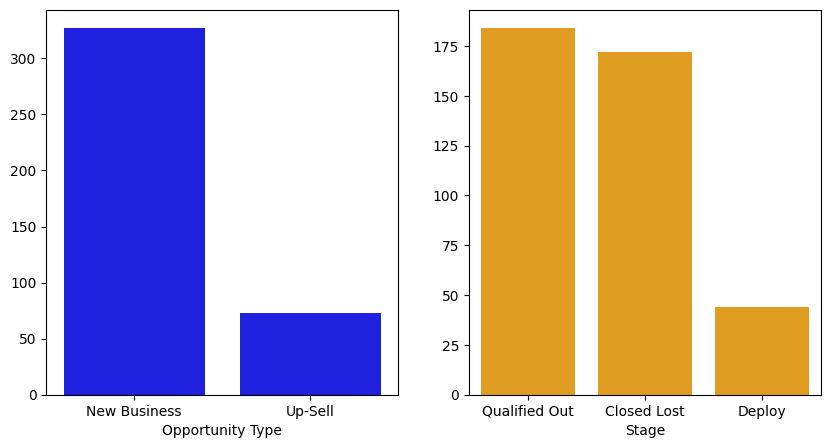

In [2671]:
plt.figure(figsize= (10,5))

plt.subplot(1, 2, 1)
sns.barplot(x=dataset['Opportunity Type'].value_counts().index, y=dataset['Opportunity Type'].value_counts().values, color='blue')

plt.subplot(1, 2, 2)
sns.barplot(x=dataset['Stage'].value_counts().index, y=dataset['Stage'].value_counts().values, color='orange')
plt.show()

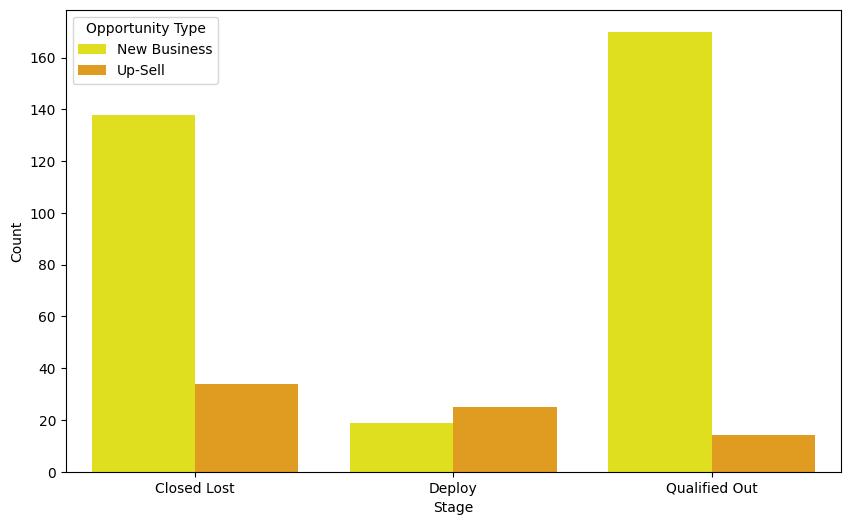

In [2672]:
# Create a summary table that actually has a column named 'Count'
summary = dataset.groupby(['Stage', 'Opportunity Type']).size().reset_index(name='Count')

plt.figure(figsize=(10, 6))

sns.barplot(
    data=summary[summary['Opportunity Type'].isin(['New Business', 'Up-Sell'])],
    x='Stage',
    y='Count',
    hue='Opportunity Type',
    palette={'New Business': 'Yellow', 'Up-Sell': 'Orange'}
)

plt.show()

In [2673]:
Win_df  = dataset[['Stage', 'Opportunity Type']].pivot_table(index='Stage', columns='Opportunity Type', aggfunc='size', fill_value=0)

Win_df

Opportunity Type,New Business,Up-Sell
Stage,,
Closed Lost,138,34
Deploy,19,25
Qualified Out,170,14


In [2674]:
Win_df['Total'] = Win_df.sum(axis=1)

Win_df

Opportunity Type,New Business,Up-Sell,Total
Stage,,,
Closed Lost,138,34,172
Deploy,19,25,44
Qualified Out,170,14,184


## Insight 1 - Volume vs wins
Total opportunities

- New Business: 
138+19+170=327

- Upsell: 
34+25+14=73.
​

Wins (Deploy)
- New Business: 19
- Upsell: 25.​

### So, New Business has far more volume, but fewer wins in absolute terms than Upsell, despite having >4× as many opportunities.
---
## Insight 2 - Win‑rate by type

This clearly shows:

The New Business funnel is very leaky: most deals end as Closed Lost or Qualified Out.

The Upsell motion is much healthier, converting roughly one‑third of its opportunities to Deploy.

---

## Conclusion :

- New Business win‑rate ≈ 19/327≈6% 19/327≈6%.​

- Upsell win‑rate ≈ 25/73≈34%.

- New Business: high volume, very low win‑rate, majority in Closed Lost + Qualified Out.

- Upsell: lower volume but higher proportion of Deploy, hence much better pipeline quality.

## Opportunity Type Vs Probability

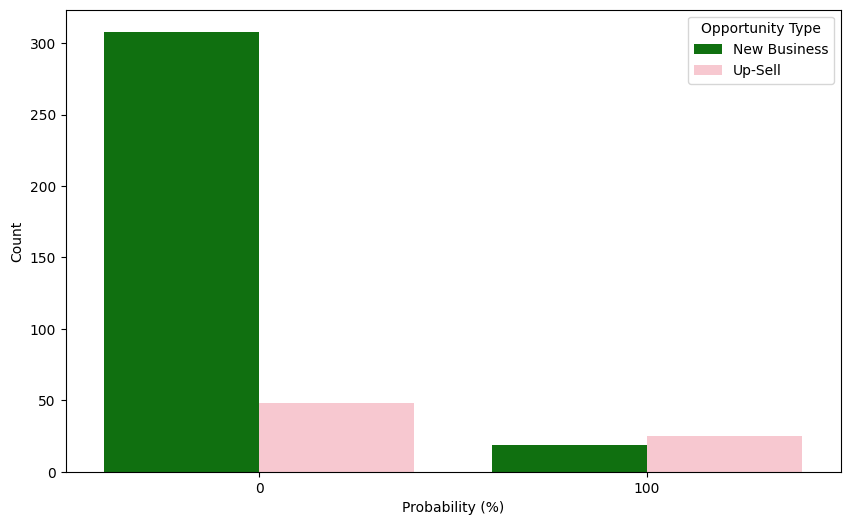

In [2675]:
# Create a summary table that actually has a column named 'Count'
summary = dataset.groupby(['Probability (%)', 'Opportunity Type']).size().reset_index(name='Count')


plt.figure(figsize=(10, 6))

sns.barplot(
    data=summary[summary['Opportunity Type'].isin(['New Business', 'Up-Sell'])],
    x='Probability (%)',
    y='Count',
    hue='Opportunity Type',
    palette={'New Business': 'Green', 'Up-Sell': 'Pink'}
)

plt.show()

In [2676]:
summary.groupby(['Probability (%)', 'Opportunity Type']).sum()

Count
Probability (%) Opportunity Type       
0               New Business        308
                Up-Sell              48
100             New Business         19
                Up-Sell              25

## Insight 3

- Almost the entire New Business pipeline and a large part of Upsell sit at 0% probability, indicating a lot of dead or non‑winnable deals in the funnel.

---

## Opportunity Owner Vs Opportunity Owner	

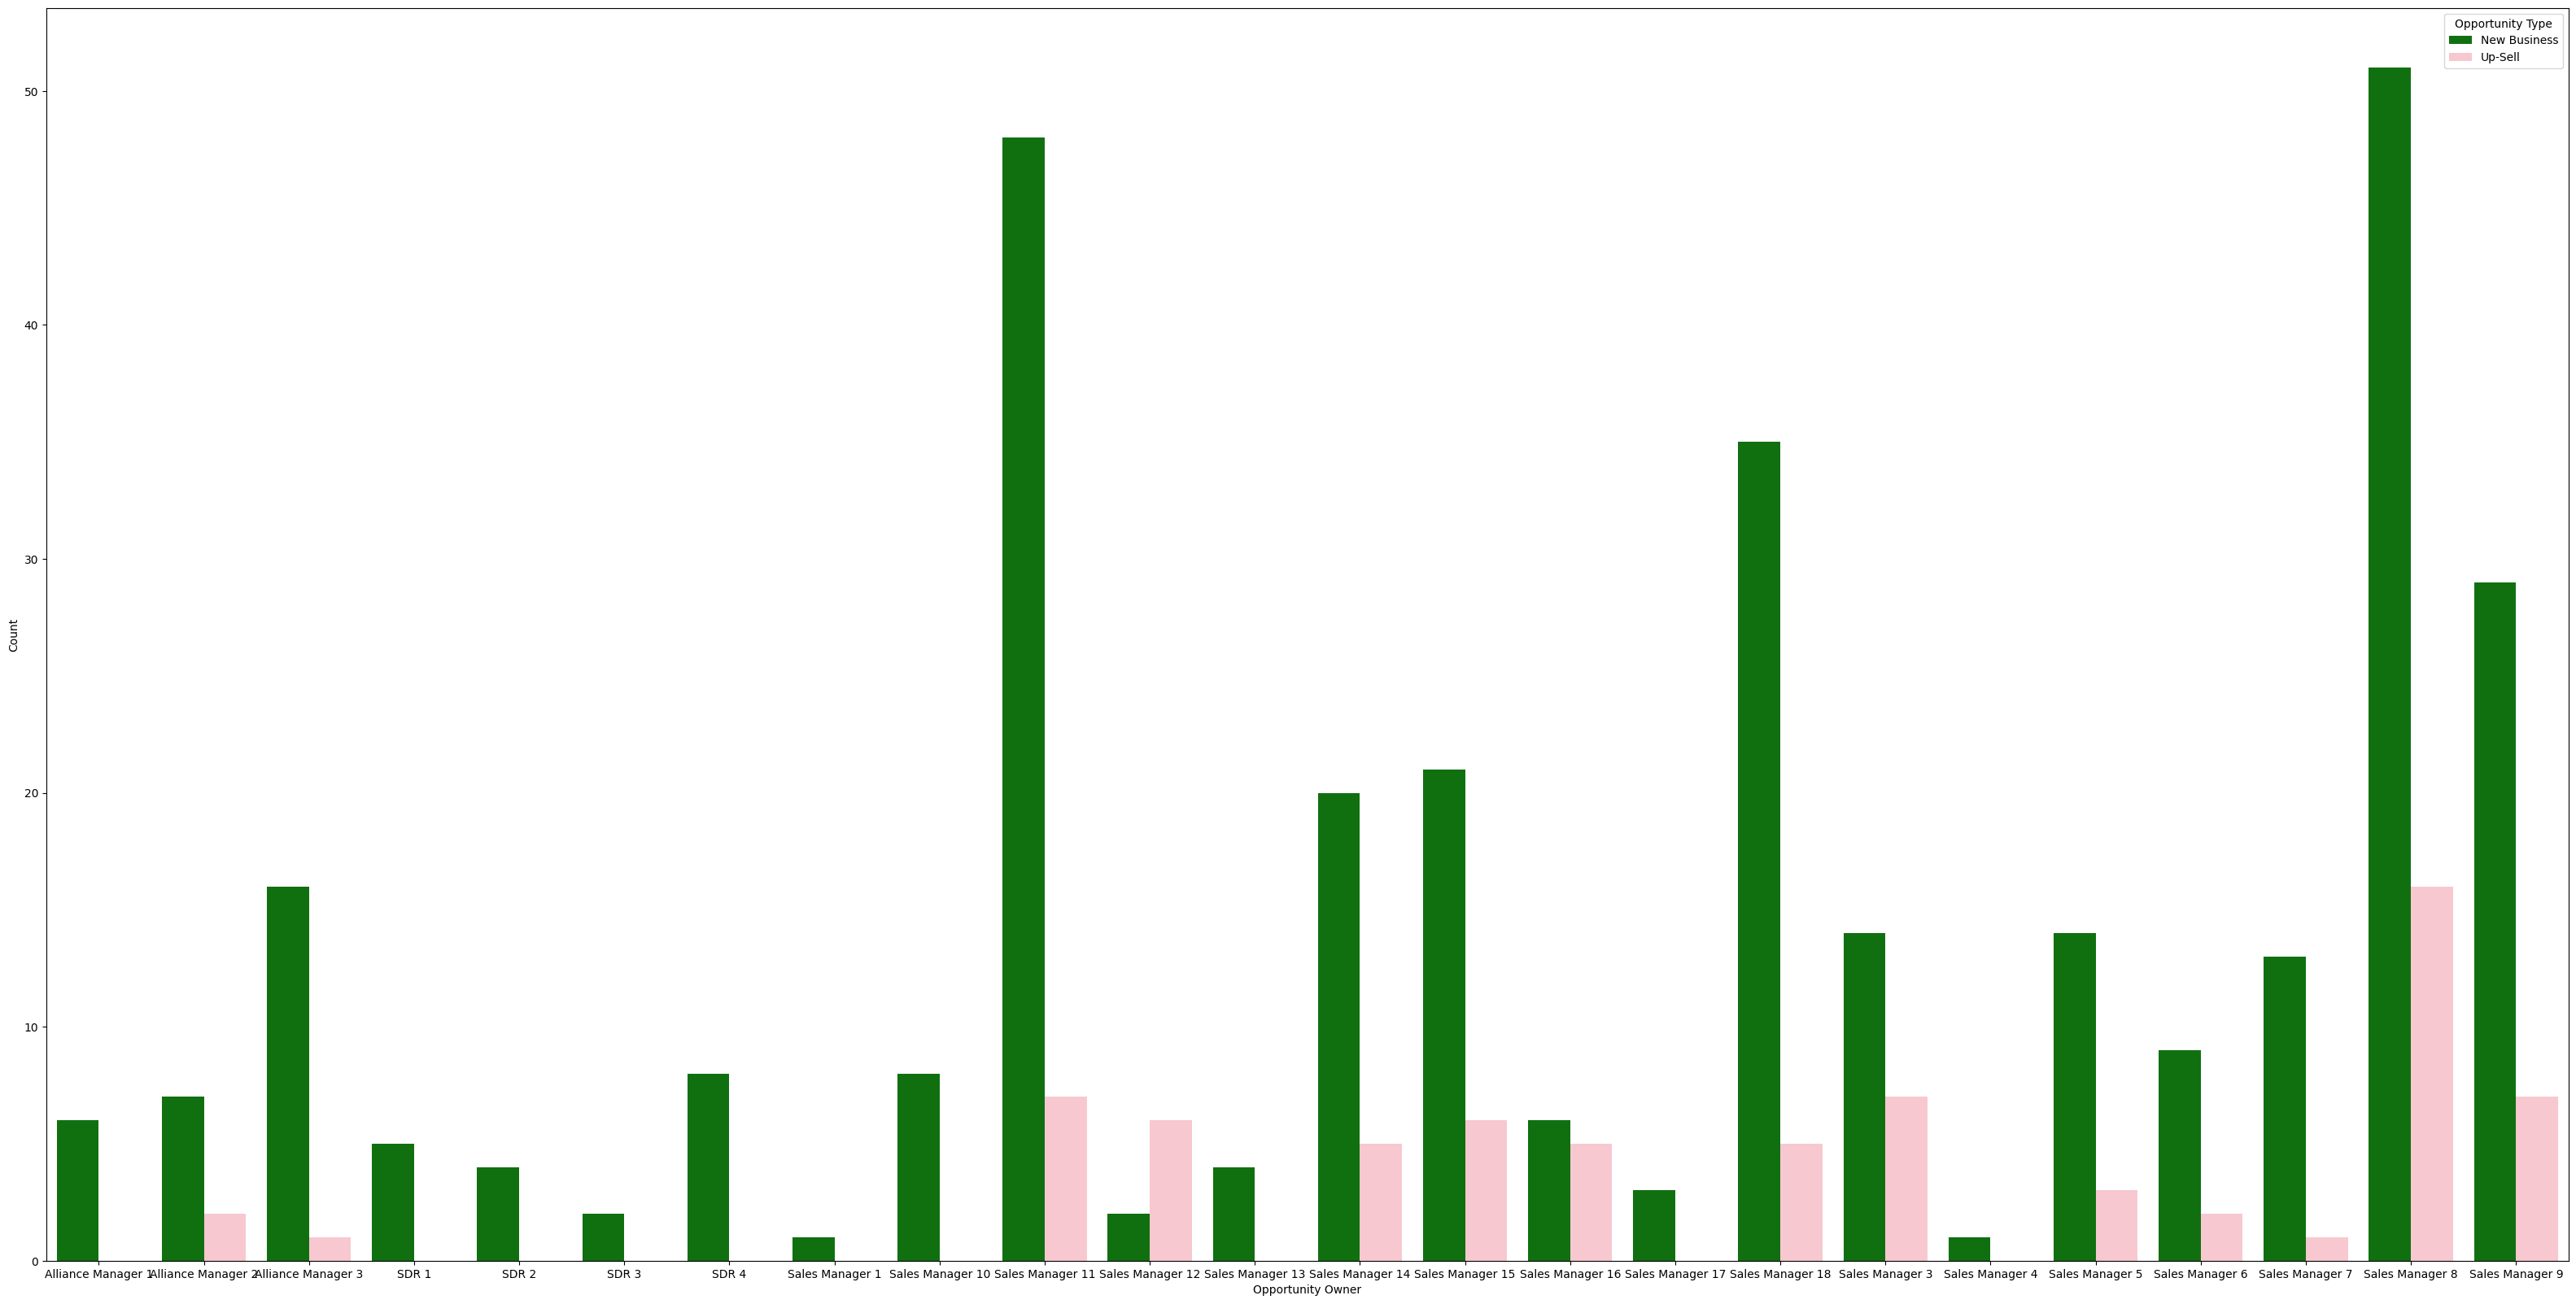

In [2677]:
# Create a summary table that actually has a column named 'Count'
summary = dataset.groupby(['Opportunity Owner', 'Opportunity Type']).size().reset_index(name='Count')

plt.figure(figsize=(40, 20))

sns.barplot(
    data=summary[summary['Opportunity Type'].isin(['New Business', 'Up-Sell'])],
    x='Opportunity Owner',
    y='Count',
    hue='Opportunity Type',
    palette={'New Business': 'Green', 'Up-Sell': 'Pink'}
)

plt.show()

In [2678]:
Owner_dataset = dataset[['Opportunity Owner', 'Opportunity Type', 'Stage']].pivot_table(index=['Opportunity Type', 'Opportunity Owner'], columns='Stage', aggfunc='size', fill_value=0).reset_index()

In [2679]:
Owner_dataset['Win Rate'] = round(Owner_dataset['Deploy'] / (Owner_dataset['Closed Lost'] + Owner_dataset['Deploy'] + Owner_dataset['Qualified Out']) * 100, 2)

In [2680]:
Owner_dataset[Owner_dataset['Win Rate'] > 0].sort_values(by=['Opportunity Type', 'Win Rate'], ascending=[True, False])

Stage,Opportunity Type,Opportunity Owner,Closed Lost,Deploy,Qualified Out,Win Rate
20,New Business,Sales Manager 6,8,1,0,11.11
12,New Business,Sales Manager 14,3,2,15,10.00
22,New Business,Sales Manager 8,33,5,13,9.80
9,New Business,Sales Manager 11,28,4,16,8.33
21,New Business,Sales Manager 7,0,1,12,7.69
23,New Business,Sales Manager 9,6,2,21,6.90
2,New Business,Alliance Manager 3,11,1,4,6.25
16,New Business,Sales Manager 18,15,2,18,5.71
13,New Business,Sales Manager 15,8,1,12,4.76
30,Up-Sell,Sales Manager 16,2,3,0,60.00


## Insight 4

- Best Opportunity Owner - Up-Sell : Sales Manager 16, Sales Manager 18	

- Best Opportunity Owner - New Business : Sales Manager 6

- Upsell owners convert far better (often 50–60%), showing a much stronger upsell motion.

- Best New Business owners still have low win rates (about 5–11%), so New Business conversion is weak overall.

---

## Opportunity Owner Vs Currency

In [2681]:
Currency_dataset = dataset[['Annual Contract Value Currency', 'Opportunity Type', 'Annual Contract Value']].pivot_table(index='Opportunity Type', columns = 'Annual Contract Value Currency', values='Annual Contract Value', aggfunc='sum', fill_value=0)

Currency_dataset

Annual Contract Value Currency,CAD,EUR,GBP,No Currency,USD
Opportunity Type,,,,,
New Business,464000.0,13825977.54,585000.0,0.0,21762481.00
Up-Sell,280000.0,1131535.00,0.0,0.0,6612481.62


<Axes: xlabel='Annual Contract Value Currency', ylabel='Opportunity Type'>

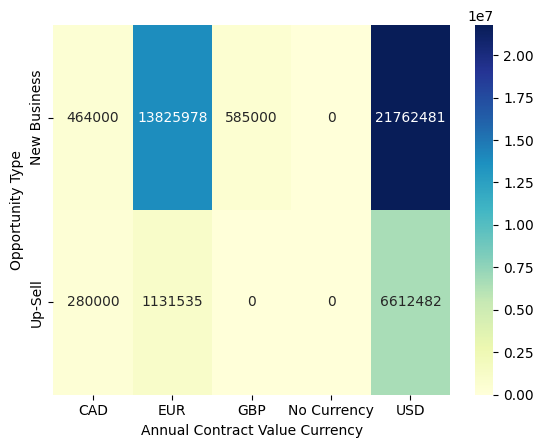

In [2682]:
sns.heatmap(Currency_dataset, annot=True, fmt='.0f', cmap='YlGnBu')

## Insight 5:
- New Business is heavily concentrated in USD and EUR (about 21.76M USD and 13.83M EUR), with much smaller totals in CAD and GBP.​

- Upsell revenue is also mainly USD and EUR, but on a smaller scale (about 6.61M USD and 1.13M EUR).
​
- This means overall revenue depends strongly on a few currencies/regions, so any slowdown or pricing issue there would hit both New Business and Upsell, which is exactly the concentration risk you are describing.

---